Device: cuda

── Collecting training samples ──

  [1] AI vs Human 2025
    ✓ 15,000 images  (REAL:7,512 FAKE:7,488)

  [2] AI Generated Images vs Real (alessandrasala79)
    ✓ 973 images  (REAL:434 FAKE:539)

  [3] tiny-GenImage
    ✓ 28,000 images  (REAL:14,000 FAKE:14,000)

  [4] Landscape pictures (real only)
    ✓ 4,000 real images

  ── Total training samples ──
  REAL : 25,946
  FAKE : 22,027
  TOTAL: 47,973

  Train : 43,176
  Val   : 4,797

── Building ViT-B/16 ──


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  Trainable (head only): 1,538 / 85,800,194

═══ Phase 1 — head only ═══
  Ep 1/3  train_loss=0.5961 acc=0.6773  val_loss=0.5225 acc=0.7455 AUC=0.8187  (626s)
  Ep 2/3  train_loss=0.4924 acc=0.7668  val_loss=0.4863 acc=0.7755 AUC=0.8493  (640s)
  Ep 3/3  train_loss=0.4699 acc=0.7823  val_loss=0.4725 acc=0.7830 AUC=0.8590  (640s)

═══ Phase 2 — full fine-tune ═══
  Ep 1/7  train_loss=0.1675 acc=0.9323  val_loss=0.0853 acc=0.9704 AUC=0.9956 ← BEST  (1759s)
  Ep 2/7  train_loss=0.0471 acc=0.9830  val_loss=0.0942 acc=0.9650 AUC=0.9958 ← BEST  (1759s)
  Ep 3/7  train_loss=0.0210 acc=0.9928  val_loss=0.0927 acc=0.9731 AUC=0.9961 ← BEST  (1760s)
  Ep 4/7  train_loss=0.0119 acc=0.9960  val_loss=0.0946 acc=0.9731 AUC=0.9965 ← BEST  (1759s)
  Ep 5/7  train_loss=0.0042 acc=0.9986  val_loss=0.0801 acc=0.9781 AUC=0.9977 ← BEST  (1757s)
  Ep 6/7  train_loss=0.0016 acc=0.9996  val_loss=0.0779 acc=0.9800 AUC=0.9982 ← BEST  (1758s)
  Ep 7/7  train_loss=0.0006 acc=0.9998  val_loss=0.0719 acc=0.9819 AUC=

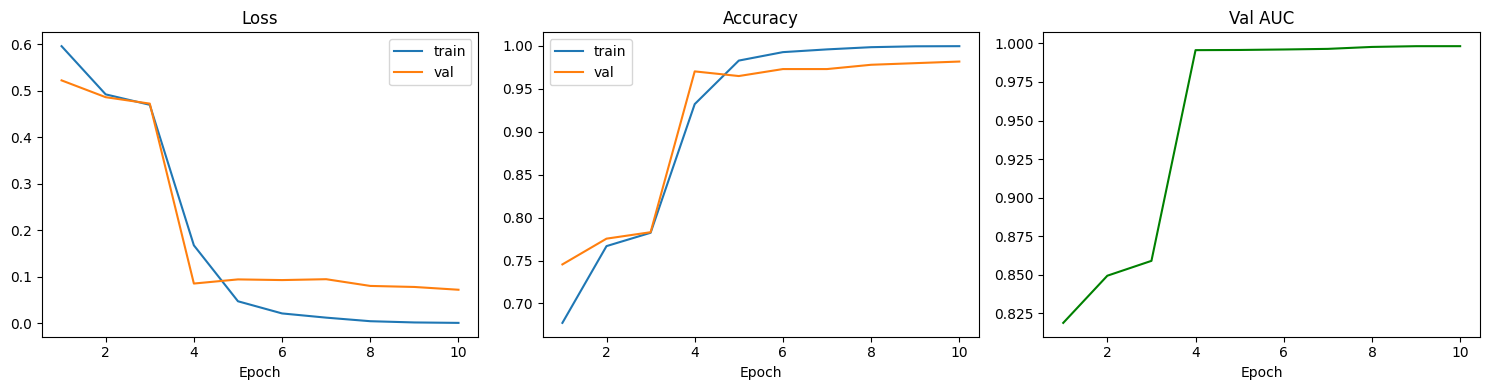


═══ Final validation evaluation ═══
              precision    recall  f1-score   support

        REAL       0.98      0.99      0.98      2559
        FAKE       0.98      0.98      0.98      2238

    accuracy                           0.98      4797
   macro avg       0.98      0.98      0.98      4797
weighted avg       0.98      0.98      0.98      4797

AUC: 0.9982


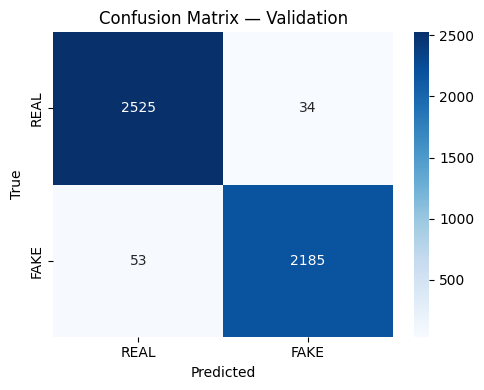


  Model ready. Use predict_image('/path/to/image.jpg') in your pipeline.
  Saved → /kaggle/working/best_vit_fake_detector_v2.pt


In [1]:
# ============================================================
#  AI-Generated Image Detector — Full Retraining (Single Cell)
#  Model   : ViT-B/16 (pretrained ImageNet, fine-tuned)
#  Data    : 4 datasets combined (see paths section below)
#  Labels  : REAL=0 | FAKE=1
# ============================================================
# HOW TO USE ON KAGGLE:
#   1. Add all 4 datasets via Data → Add Data
#   2. Add your test dataset (tristanzhang32) — DO NOT use for training
#   3. Enable GPU T4 in Settings → Accelerator
#   4. Fill in the paths section below
#   5. Run this single cell
# ============================================================

import os, random, time, copy, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import torchvision.transforms as T
import timm

# ── reproducibility ──────────────────────────────────────────
random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ============================================================
# FILL IN YOUR PATHS HERE
# ============================================================
# Dataset 1: AI vs Human 2025 competition
# structure: train_data/ with train.csv (has image paths + labels)
AI_VS_HUMAN_ROOT   = "/kaggle/input/datasets/alessandrasala79/ai-vs-human-generated-dataset"

# Dataset 2: AI Generated Images vs Real (alessandrasala79)
# structure: AiArtData/AiArtData/ and RealArt/RealArt/
AI_ART_FAKE_FOLDER = "/kaggle/input/datasets/cashbowman/ai-generated-images-vs-real-images/AiArtData"
AI_ART_REAL_FOLDER = "/kaggle/input/datasets/cashbowman/ai-generated-images-vs-real-images/RealArt"

# Dataset 3: tiny-GenImage
# structure: per generator / train / ai or nature
GENIMAGE_ROOT      = "/kaggle/input/datasets/yangsangtai/tiny-genimage"

# Dataset 4: Landscape pictures (real only)
# structure: flat folder with .jpg images
LANDSCAPE_FOLDER   = "/kaggle/input/datasets/arnaud58/landscape-pictures"

# Model save path
SAVE_PATH          = "/kaggle/working/best_vit_fake_detector_v2.pt"
# ============================================================

# ── hyperparameters ──────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
PHASE1_EPOCHS   = 3      # head only
PHASE2_EPOCHS   = 7      # full fine-tune
LR_HEAD         = 1e-4
LR_FULL         = 1e-5
MAX_PER_SOURCE  = 15000  # cap each source to keep training balanced

# ── transforms ───────────────────────────────────────────────
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

# ── generic dataset class ─────────────────────────────────────
class ImagePairDataset(Dataset):
    """
    Accepts a list of (path, label) tuples.
    REAL=0, FAKE=1
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            # if image is corrupted return a black image
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE))
        if self.transform: img = self.transform(img)
        return img, label


def collect_images(folder, label, cap=MAX_PER_SOURCE):
    """Walk a folder recursively and collect up to cap images."""
    samples = []
    for dirpath, _, fnames in os.walk(folder):
        for fname in fnames:
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                samples.append((os.path.join(dirpath, fname), label))
    random.shuffle(samples)
    return samples[:cap]


# ── collect all samples ───────────────────────────────────────
print("\n── Collecting training samples ──")
all_train_samples = []

# ── Dataset 1: AI vs Human 2025 ──────────────────────────────
# This dataset uses a CSV file with columns: id, label (0=real, 1=fake)
# Images are in train_data/ folder
print("\n  [1] AI vs Human 2025")
try:
    import pandas as pd
    train_csv = os.path.join(AI_VS_HUMAN_ROOT, "train.csv")
    train_img_folder = os.path.join(AI_VS_HUMAN_ROOT, "train_data")

    if os.path.isfile(train_csv) and os.path.isdir(train_img_folder):
        df = pd.read_csv(train_csv)
        # expected columns: 'id' (filename) and 'label' (0 or 1)
        label_col = "label"
        samples_1 = []
        for _, row in df.iterrows():
            # file_name already contains "train_data/filename.jpg"
            path = os.path.join(AI_VS_HUMAN_ROOT, str(row["file_name"]))
            if os.path.isfile(path):
                samples_1.append((path, int(row[label_col])))
        
        random.shuffle(samples_1)
        samples_1 = samples_1[:MAX_PER_SOURCE]
        all_train_samples.extend(samples_1)
        r = sum(1 for _,l in samples_1 if l==0)
        f = sum(1 for _,l in samples_1 if l==1)
        print(f"    ✓ {len(samples_1):,} images  (REAL:{r:,} FAKE:{f:,})")
    else:
        print(f"    ✗ CSV or folder not found — check AI_VS_HUMAN_ROOT path")
except Exception as e:
    print(f"    ✗ Error loading AI vs Human dataset: {e}")

# ── Dataset 2: AI Art (alessandrasala79) ──────────────────────
print("\n  [2] AI Generated Images vs Real (alessandrasala79)")
try:
    fake_samples_2 = collect_images(AI_ART_FAKE_FOLDER, label=1)
    real_samples_2 = collect_images(AI_ART_REAL_FOLDER, label=0)
    samples_2 = fake_samples_2 + real_samples_2
    all_train_samples.extend(samples_2)
    print(f"    ✓ {len(samples_2):,} images  "
          f"(REAL:{len(real_samples_2):,} FAKE:{len(fake_samples_2):,})")
except Exception as e:
    print(f"    ✗ Error: {e}")

# ── Dataset 3: tiny-GenImage ──────────────────────────────────
print("\n  [3] tiny-GenImage")
try:
    REAL_FOLDERS_GEN = {"imagenet", "nature", "real"}
    gen_real, gen_fake = [], []
    for gen in os.listdir(GENIMAGE_ROOT):
        gen_path = os.path.join(GENIMAGE_ROOT, gen, "train")
        if not os.path.isdir(gen_path): continue
        # ai subfolder = FAKE
        ai_path = os.path.join(gen_path, "ai")
        if os.path.isdir(ai_path):
            gen_fake.extend(collect_images(ai_path, label=1, cap=2000))
        # nature subfolder = REAL
        nat_path = os.path.join(gen_path, "nature")
        if os.path.isdir(nat_path):
            gen_real.extend(collect_images(nat_path, label=0, cap=2000))
    samples_3 = gen_real + gen_fake
    all_train_samples.extend(samples_3)
    print(f"    ✓ {len(samples_3):,} images  "
          f"(REAL:{len(gen_real):,} FAKE:{len(gen_fake):,})")
except Exception as e:
    print(f"    ✗ Error: {e}")

# ── Dataset 4: Landscape pictures (real only) ─────────────────
print("\n  [4] Landscape pictures (real only)")
try:
    landscape_samples = collect_images(LANDSCAPE_FOLDER, label=0, cap=4000)
    all_train_samples.extend(landscape_samples)
    print(f"    ✓ {len(landscape_samples):,} real images")
except Exception as e:
    print(f"    ✗ Error: {e}")

# ── final stats ───────────────────────────────────────────────
random.shuffle(all_train_samples)
total_real = sum(1 for _, l in all_train_samples if l == 0)
total_fake = sum(1 for _, l in all_train_samples if l == 1)
print(f"\n  ── Total training samples ──")
print(f"  REAL : {total_real:,}")
print(f"  FAKE : {total_fake:,}")
print(f"  TOTAL: {len(all_train_samples):,}")

# ── balance if heavily skewed ─────────────────────────────────
min_class = min(total_real, total_fake)
if max(total_real, total_fake) / min_class > 2.0:
    print(f"\n  [!] Imbalance detected — balancing to {min_class:,} each")
    real_s = [(p,l) for p,l in all_train_samples if l==0][:min_class]
    fake_s = [(p,l) for p,l in all_train_samples if l==1][:min_class]
    all_train_samples = real_s + fake_s
    random.shuffle(all_train_samples)
    print(f"  Balanced total: {len(all_train_samples):,}")

# ── train / val split ─────────────────────────────────────────
val_size   = int(0.1 * len(all_train_samples))
train_size = len(all_train_samples) - val_size
train_list = all_train_samples[:train_size]
val_list   = all_train_samples[train_size:]

train_dataset = ImagePairDataset(train_list, transform=train_tf)
val_dataset   = ImagePairDataset(val_list,   transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"\n  Train : {len(train_dataset):,}")
print(f"  Val   : {len(val_dataset):,}")

# ── build model ───────────────────────────────────────────────
print("\n── Building ViT-B/16 ──")
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2)

# Phase 1: freeze backbone
for name, param in model.named_parameters():
    if "head" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"  Trainable (head only): {trainable:,} / {total_p:,}")
model = model.to(device)

# ── training helpers ──────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out   = model(imgs)
            loss  = criterion(out, labels)
            probs = torch.softmax(out, dim=1)[:, 1]
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / total, correct / total, auc

# ── training history ──────────────────────────────────────────
history  = {"train_loss":[], "val_loss":[],
            "train_acc":[],  "val_acc":[], "val_auc":[]}
best_auc = 0.0
best_wts = None

# ── Phase 1: head only ────────────────────────────────────────
print("\n═══ Phase 1 — head only ═══")
opt1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
for ep in range(PHASE1_EPOCHS):
    t0 = time.time()
    tl, ta = train_one_epoch(model, train_loader, opt1)
    vl, va, vauc = evaluate(model, val_loader)
    for k, v in zip(history, [tl, vl, ta, va, vauc]):
        history[k].append(v)
    print(f"  Ep {ep+1}/{PHASE1_EPOCHS}  "
          f"train_loss={tl:.4f} acc={ta:.4f}  "
          f"val_loss={vl:.4f} acc={va:.4f} AUC={vauc:.4f}  "
          f"({time.time()-t0:.0f}s)")

# ── Phase 2: full fine-tune ───────────────────────────────────
print("\n═══ Phase 2 — full fine-tune ═══")
for param in model.parameters():
    param.requires_grad = True

opt2  = torch.optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=PHASE2_EPOCHS)

for ep in range(PHASE2_EPOCHS):
    t0 = time.time()
    tl, ta = train_one_epoch(model, train_loader, opt2)
    vl, va, vauc = evaluate(model, val_loader)
    sched.step()
    for k, v in zip(history, [tl, vl, ta, va, vauc]):
        history[k].append(v)
    tag = " ← BEST" if vauc > best_auc else ""
    if vauc > best_auc:
        best_auc = vauc
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts, SAVE_PATH)
    print(f"  Ep {ep+1}/{PHASE2_EPOCHS}  "
          f"train_loss={tl:.4f} acc={ta:.4f}  "
          f"val_loss={vl:.4f} acc={va:.4f} AUC={vauc:.4f}{tag}  "
          f"({time.time()-t0:.0f}s)")

print(f"\n  Best val AUC: {best_auc:.4f} → saved to {SAVE_PATH}")

# ── training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep_range  = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep_range, history["train_loss"], label="train")
axes[0].plot(ep_range, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(ep_range, history["train_acc"],  label="train")
axes[1].plot(ep_range, history["val_acc"],    label="val")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(ep_range, history["val_auc"], color="green")
axes[2].set_title("Val AUC"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_v2.png", dpi=120)
plt.show()

# ── final val evaluation ──────────────────────────────────────
print("\n═══ Final validation evaluation ═══")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_preds, all_labels_val, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        out  = model(imgs)
        probs = torch.softmax(out, dim=1)[:, 1]
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels_val.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

print(classification_report(all_labels_val, all_preds,
                             target_names=["REAL", "FAKE"]))
print(f"AUC: {roc_auc_score(all_labels_val, all_probs):.4f}")

cm = confusion_matrix(all_labels_val, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["REAL", "FAKE"],
            yticklabels=["REAL", "FAKE"], cmap="Blues")
plt.title("Confusion Matrix — Validation")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_v2.png", dpi=120)
plt.show()

# ── inference function for your pipeline ─────────────────────
def predict_image(image_path):
    """
    Returns P(AI-generated) — plug this into your fake news pipeline.
    Usage: result = predict_image("/path/to/image.jpg")
    """
    model.load_state_dict(torch.load(SAVE_PATH))
    model.eval()
    img    = Image.open(image_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.softmax(model(tensor), dim=1)[0][1].item()
    return {
        "ai_generated_probability" : round(prob, 4),
        "label"                    : "FAKE" if prob > 0.5 else "REAL",
        "confidence_pct"           : round(max(prob, 1 - prob) * 100, 2)
    }

print("\n  Model ready. Use predict_image('/path/to/image.jpg') in your pipeline.")
print(f"  Saved → {SAVE_PATH}")